In [1]:
import pandas as pd

# household_id explicitly as str -- never let this ID column round-trip
# through a numeric dtype (see CLAUDE.md's float-precision gotcha; it's what
# caused the false "duplicates" found and fixed further down this notebook).
df = pd.read_csv("../data/processed/crop_loss_master_all.csv", low_memory=False, dtype={"household_id": str})
print(df.shape)
df.head()

(75077, 94)


,household_id,crop_code,crop_name,crop_domain,disposition_share1_pct_unconfirmed,disposition_share2_pct_unconfirmed,disposition_share3_pct_unconfirmed,disposition_share4_pct_unconfirmed,disposition_share5_pct_unconfirmed,disposition_share6_pct_unconfirmed,...,woreda_code,is_rural,survey_year,region_name,rainfall_belg_mm,rainfall_belg_pct_of_avg,rainfall_meher_mm,rainfall_meher_pct_of_avg,rainfall_annual_mm,rainfall_annual_pct_of_avg
0,1010101601002,2.0,MAIZE,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
1,1010101601002,3.0,MILLET,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
2,1010101601002,6.0,SORGHUM,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
3,1010101601002,38.0,RED PEPPER,garden_crop,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
4,1010101601017,2.0,MAIZE,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3


In [2]:
pd.set_option("display.max_rows", 100)
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(1)
missing.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
loss_detail_ka_unconfirmed,75001,99.9
loss_detail_la_unconfirmed,75001,99.9
loss_detail_z_unconfirmed,75002,99.9
loss_detail_x_unconfirmed,74982,99.9
loss_detail_w_unconfirmed,74975,99.9
loss_detail_v_unconfirmed,74968,99.9
loss_detail_pa_unconfirmed,75007,99.9
loss_detail_oa_unconfirmed,75011,99.9
loss_detail_na_unconfirmed,75008,99.9
loss_detail_t_unconfirmed,74904,99.8


## Defining the target, then dropping leakage / unreliable columns

`total_loss_qty` (and the `loss_reason1/2/3_occurred/unit/qty` columns it's
built from) can only be used to build the **target** — using them as
**features** would be leakage, since they directly encode the outcome being
predicted. Built `loss_occurred` from `total_loss_qty` first, then those
columns (plus everything else too sparse/ambiguous to trust — see below) are
dropped from the feature set entirely.

In [3]:
# Target: was any loss recorded for this household+crop+wave row.
df["loss_occurred"] = (df["total_loss_qty"].fillna(0) > 0).astype(int)
print(df["loss_occurred"].value_counts(normalize=True).rename("share").round(3))

# Leakage: total_loss_qty and everything it's built from.
LEAKAGE_COLS = [
    "total_loss_qty",
    "loss_reason1_occurred", "loss_reason1_unit", "loss_reason1_qty",
    "loss_reason2_occurred", "loss_reason2_unit", "loss_reason2_qty",
    "loss_reason3_occurred", "loss_reason3_unit", "loss_reason3_qty",
]

# loss_detail_* / loss_extra_*: 70-99.9% missing, and several describe the
# circumstances of the loss itself (leakage risk on top of sparsity).
LOSS_DETAIL_COLS = [c for c in df.columns if c.startswith("loss_detail_") or c.startswith("loss_extra_")]

# storage_*_unconfirmed: 69-98% missing, too sparse to trust.
STORAGE_UNCONFIRMED_COLS = [c for c in df.columns if c.startswith("storage_")]

# disposition_*: 45-46% missing (absent entirely for Waves 2018/2021) and
# ambiguous timing relative to the loss event.
DISPOSITION_COLS = [c for c in df.columns if c.startswith("disposition_")]

# Redundant with crop_code/crop_name identity, and 35% missing.
CROP_DOMAIN_COLS = ["crop_domain"]

# zone_code is a per-region local sequence, not nationally unique/comparable
# without pairing to region_code -- not usable as-is.
GEO_COLS = ["zone_code", "woreda_code"]

# Semantics unconfirmed, 82-84% missing.
UNCONFIRMED_MISC_COLS = ["ph_saq07", "ph_saq07_loss"]

DROP_COLS = (
    LEAKAGE_COLS + LOSS_DETAIL_COLS + STORAGE_UNCONFIRMED_COLS
    + DISPOSITION_COLS + CROP_DOMAIN_COLS + GEO_COLS + UNCONFIRMED_MISC_COLS
)
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

print(f"\ndropping {len(DROP_COLS)} columns")
df_model = df.drop(columns=DROP_COLS)
print("remaining shape:", df_model.shape)
print(list(df_model.columns))

loss_occurred
0    0.935
1    0.065
Name: share, dtype: float64

dropping 80 columns
remaining shape: (75077, 15)
['household_id', 'crop_code', 'crop_name', 'household_size', 'region_code', 'is_rural', 'survey_year', 'region_name', 'rainfall_belg_mm', 'rainfall_belg_pct_of_avg', 'rainfall_meher_mm', 'rainfall_meher_pct_of_avg', 'rainfall_annual_mm', 'rainfall_annual_pct_of_avg', 'loss_occurred']


## Check for missing values

In [4]:
missing_val = df_model.isna().sum().to_frame("missing_count").sort_values("missing_count", ascending=False)
missing_val


,missing_count
crop_name,3883
crop_code,1024
household_size,381
region_code,381
is_rural,381
region_name,381
rainfall_belg_mm,381
rainfall_belg_pct_of_avg,381
rainfall_meher_mm,381
rainfall_meher_pct_of_avg,381


## Missing values in percentage

In [5]:
missing_val_percent = (missing_val / len(df_model) * 100).round(1)
missing_val_percent

,missing_count
crop_name,5.2
crop_code,1.4
household_size,0.5
region_code,0.5
is_rural,0.5
region_name,0.5
rainfall_belg_mm,0.5
rainfall_belg_pct_of_avg,0.5
rainfall_meher_mm,0.5
rainfall_meher_pct_of_avg,0.5


## Handling the remaining missing values

All under 6%, so no column is worth dropping outright — but the two patterns
have different causes and need different treatment, not one blanket
imputation rule:

- `region_code`/`region_name`/`household_size`/`is_rural`/all 6 rainfall
  columns are missing on the **same 381 rows** (0.5%) — the known
  household-join gap, not scattered noise. Imputing a region or rainfall
  value for these would mean guessing geography/weather for a row where it's
  genuinely unknown, and rainfall is one of the few real predictive signals
  here — a wrong guess would hurt more than the row is worth. **Dropped**
  instead; 0.5% of 75,077 rows is negligible.
- `crop_code`/`crop_name` are missing independently (1.4% / 5.2%) of the
  above. Mode-imputing (e.g. filling with "MAIZE", the most common crop)
  would bias the model toward that crop's loss pattern for rows that may not
  even be that crop. Instead, **recoded as an explicit "Unknown" category**
  — since crop identity will be categorically encoded anyway, this keeps the
  ~3,900 rows' `loss_occurred` label instead of discarding them, and lets
  the model learn a baseline rate for "crop not identified" separately.

In [6]:
# Drop the household-join-gap rows (region_code missing implies the whole
# household-level cluster is missing for that row).
before = len(df_model)
df_model = df_model[df_model["region_code"].notna()].copy()
print(f"dropped {before - len(df_model)} rows with missing household-level fields")

# Recode missing crop identity as an explicit "Unknown" category instead of
# dropping or mode-imputing.
df_model["crop_code"] = df_model["crop_code"].fillna(-1)
df_model["crop_name"] = df_model["crop_name"].fillna("UNKNOWN")

print("\nfinal shape:", df_model.shape)
print("\nremaining missing values:")
print(df_model.isna().sum())

dropped 381 rows with missing household-level fields

final shape: (74696, 15)

remaining missing values:
household_id                  0
crop_code                     0
crop_name                     0
household_size                0
region_code                   0
is_rural                      0
survey_year                   0
region_name                   0
rainfall_belg_mm              0
rainfall_belg_pct_of_avg      0
rainfall_meher_mm             0
rainfall_meher_pct_of_avg     0
rainfall_annual_mm            0
rainfall_annual_pct_of_avg    0
loss_occurred                 0
dtype: int64


## Check for duplicate rows

Two checks: exact full-row duplicates, and duplicates on the row's natural
grain (`household_id` + `crop_code` + `crop_name` + `survey_year`) — the
pipeline is supposed to guarantee one row per household+crop+wave, so any
grain duplicates here would point to a merge bug upstream in Part 6.

**This caught a real bug, now fixed upstream in `01_data_exploration.ipynb`.**
A single raw row in Wave 3 (2015)'s loss file had a missing `household_id`,
which forced pandas to read that whole column as `float64` on load; dropping
the bad row afterward didn't undo the dtype. That `float64` column then
forced Part 6's `pd.concat` to promote the *entire* combined `household_id`
column to `float64` — silently corrupting Waves 2018/2021's otherwise-exact
17-18 digit integer IDs (float64 only represents integers exactly up to
2**53). Distinct households whose IDs happened to be close together (e.g.
sequentially assigned within the same enumeration area) collapsed onto the
same rounded value, which is what showed up here as ~740 "duplicate" rows.
Fixed at the source (Part 4 casts Wave 3's `household_id` back to `int64`
after dropping the bad row) and with a defense-in-depth read (Part 6 now
reads every wave's `household_id` as `str`, immune to this regardless of any
wave's own dtype). Re-running this cell below should now show 0 duplicates.

In [7]:
full_row_dupes = df_model.duplicated().sum()
print("full-row duplicates:", full_row_dupes)

GRAIN = ["household_id", "crop_code", "crop_name", "survey_year"]
grain_dupes = df_model.duplicated(subset=GRAIN).sum()
print("duplicates on (household_id, crop_code, crop_name, survey_year):", grain_dupes)

if grain_dupes:
    df_model[df_model.duplicated(subset=GRAIN, keep=False)].sort_values(GRAIN).head(20)

full-row duplicates: 0
duplicates on (household_id, crop_code, crop_name, survey_year): 0


## Plot 1 — Loss rate by rainfall

Bucketing `rainfall_meher_pct_of_avg` (Meher-season rainfall as % of the
long-term average) into drought/normal/excess checks for a threshold effect
that a single correlation number would hide — loss risk could plausibly
rise with either too little rain (drought stress) or too much (waterlogging,
mold), not move linearly in one direction.

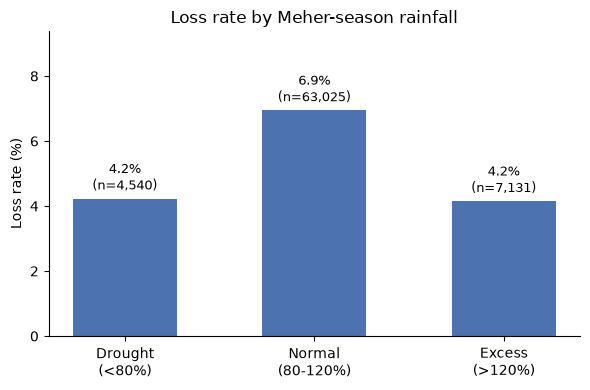

In [8]:
import matplotlib.pyplot as plt

BAR_COLOR = "#4C72B0"


def rain_bucket(pct):
    if pct < 80:
        return "Drought\n(<80%)"
    if pct > 120:
        return "Excess\n(>120%)"
    return "Normal\n(80-120%)"


df_model["meher_rain_bucket"] = df_model["rainfall_meher_pct_of_avg"].apply(rain_bucket)
bucket_order = ["Drought\n(<80%)", "Normal\n(80-120%)", "Excess\n(>120%)"]
loss_by_bucket = (df_model.groupby("meher_rain_bucket")["loss_occurred"].mean() * 100).reindex(bucket_order)
counts_by_bucket = df_model["meher_rain_bucket"].value_counts().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(loss_by_bucket.index, loss_by_bucket.values, color=BAR_COLOR, width=0.55)
ax.set_ylabel("Loss rate (%)")
ax.set_title("Loss rate by Meher-season rainfall")
ax.spines[["top", "right"]].set_visible(False)
for bar, val, n in zip(bars, loss_by_bucket.values, counts_by_bucket.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, f"{val:.1f}%\n(n={n:,})",
             ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, loss_by_bucket.max() * 1.35)
plt.tight_layout()
plt.show()

## Plot 2 — Loss rate by region and by crop

Horizontal bar charts, sorted by loss rate, for the categorical features
most likely to separate the classes: all 10 regions present in the data, and
the 15 most common crops (by row count) — rare crops are excluded here since
a loss rate computed on a handful of rows isn't a reliable signal.

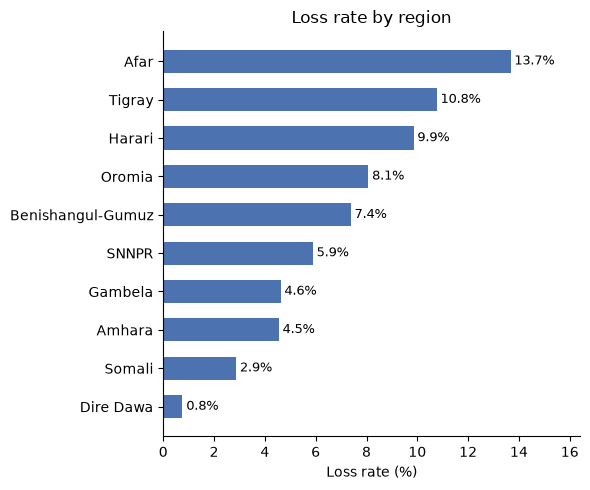

In [9]:
loss_by_region = (df_model.groupby("region_name")["loss_occurred"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.barh(loss_by_region.index, loss_by_region.values, color=BAR_COLOR, height=0.6)
ax.set_xlabel("Loss rate (%)")
ax.set_title("Loss rate by region")
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, loss_by_region.values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, loss_by_region.max() * 1.2)
plt.tight_layout()
plt.show()

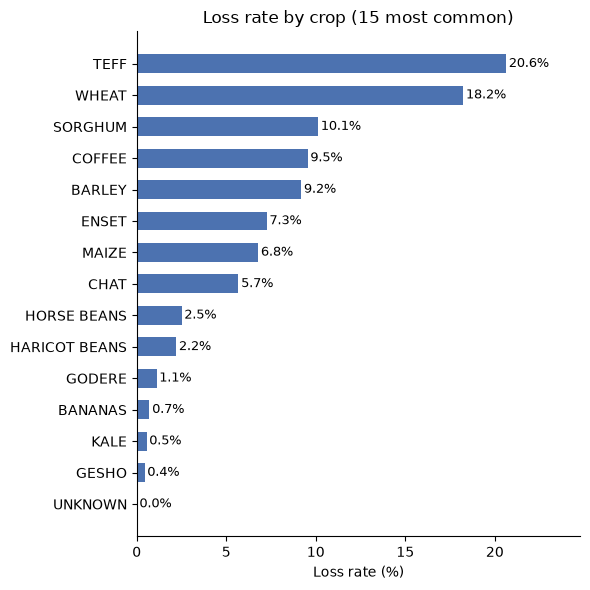

In [10]:
top_crops = df_model["crop_name"].value_counts().head(15).index
loss_by_crop = (
    df_model[df_model["crop_name"].isin(top_crops)]
    .groupby("crop_name")["loss_occurred"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.barh(loss_by_crop.index, loss_by_crop.values, color=BAR_COLOR, height=0.6)
ax.set_xlabel("Loss rate (%)")
ax.set_title("Loss rate by crop (15 most common)")
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, loss_by_crop.values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, loss_by_crop.max() * 1.2)
plt.tight_layout()
plt.show()